# Resonance & peak-amplitude summary

Overlays one or more `KineticEnergy_summary_<region>.csv` tables (from
`batch_KineticEnergy` / `single_KineticEnergy`) on a single figure -- two panels,
mean(Ek) and std(Ek) versus $f^*$ = f_lib/f_rot (exactly like the batch
notebook). **Each summary file is drawn
with its own marker and colour**, so several datasets / regions / `k0` can be
compared at a glance; within a file each dphi sweep is connected. Each file's
`k0` is read from its dataset's `param_postProcessing.json` and shown in the
legend.

Set these in the config cell, then run all cells:

| option | meaning |
|---|---|
| `SUMMARY_FILES` | list of summary CSVs to overlay (full paths) |
| `REGION` | `'ROI'` / `'FULL'` — only used to build the default file list + output name |
| `FIG_FORMAT` | `'png'` or `'pdf'` — saved-figure format |
| `OUTPUT_STEM` | output path stem; `None` -> beside the first summary file |

Both a raw and a normalized figure (using the `mean_Ekin_star` / `std_Ekin_star`
columns, Ek / E_lib) are written; the name gets `[_normalized]`, so the variants
never overwrite each other. Saving is skipped while a filter is active.

It also builds, from the sibling `VelocityFFT_summary_<region>.csv` of each file, two peak-amplitude figures versus `f_lib` (each two panels, normalized `/U0` left, raw right):

- amplitude of the peak at `f_lib`,
- amplitude of the peaks at `f_low`, `f_lib-f_low`, `f_lib+f_low`.

All figures whose name contains `overlay` are saved in the dataset root `_CEG`.

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import piv_postprocessing_lib as ppl
from piv_postprocessing_lib import (topography_arrangement, figure_filename, libration_ke_scale,
                        read_paramPostprocessing, region_tag)

%matplotlib widget


In [7]:
# --- Mute switch -----------------------------------------------------------
# MUTE_PRINT = True silences ALL print() output (this notebook AND the library),
# so a running batch stays quiet while you edit other files. Re-run this cell to
# toggle. (Figures are unaffected.)
import builtins
if not hasattr(builtins, "_piv_real_print"):
    builtins._piv_real_print = builtins.print
MUTE_PRINT = False
builtins.print = (lambda *a, **k: None) if MUTE_PRINT else builtins._piv_real_print

# Region tag used to build the default file list and the output name.
REGION = 'ROI'


# Saved-figure format: 'png' or 'pdf'. Raw + '_normalized' versions are written.
FIG_FORMAT = 'png'

tag = region_tag(REGION)

# Summary CSVs to OVERLAY on one figure -- one marker/colour per file. Full
# paths; mix regions / datasets / k0 freely. k0 for each is read from its
# dataset's param_postProcessing.json and shown in the legend.
_CEG = ("/Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/"
        "TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA")
SUMMARY_FILES = [
    os.path.join(_CEG, "k6_TopBottom", "KineticEnergy_summary_%s.csv" % tag),
    os.path.join(_CEG, "k20_bottomOnly", "KineticEnergy_summary_%s.csv" % tag),
    os.path.join(_CEG, "k6_bottomOnly", "KineticEnergy_summary_%s.csv" % tag)
]

# Figure output stem (xaxis/normalized appended). None -> beside the 1st summary.
OUTPUT_STEM = None

# Filtering: None (all), a value, a list [0.40, 0.44], or a (lo, hi) RANGE
# tuple e.g. (0.1, 1.0) -- inclusive. (Applied in the filter cell below.)
SELECT_FROT  = 0.5     # Hz,  e.g. 0.5
SELECT_FLIB  = None    # Hz,  e.g. 0.44  or  [0.40, 0.44]
SELECT_FSTAR = (0,1)    # e.g. 3.0  or  (0.1, 1.0) for a range
SELECT_DPHI  = 2    # deg, e.g. 2.0

# Topography selection: one of
#   'all'            -> any topography (no filter)
#   'bottom only'    -> bottomOnly datasets  (top=False, bottom=True)
#   'top and bottom' -> TopBottom datasets   (top=True,  bottom=True)
SELECT_TOPO = "all"


In [8]:
def load_summary(path):
    """Read the summary table from .xlsx or .csv into a DataFrame."""
    ext = os.path.splitext(path)[1].lower()
    if ext in (".xlsx", ".xls"):
        return pd.read_excel(path)
    if ext == ".csv":
        return pd.read_csv(path)
    raise ValueError("Unsupported summary format: %s" % ext)

In [9]:
MARKERS = ["o", "s", "^", "D", "v", "P", "*", "X", "h", "<"]


def draw_summary(axes, summaries, normalize=True):
    """Draw mean(Ek) and std(Ek) vs f* into the two supplied axes.

    Returns True if anything was plotted. One curve per (f_rot, dphi) sweep,
    labelled by k0 (from the file's param), dphi and f_rot. normalize=True uses
    the mean_Ekin_star / std_Ekin_star columns (Ek / E_lib); False the raw ones.
    The figure itself is created by the caller so the %matplotlib widget backend
    displays it interactively.
    """
    xcol = "fstar"
    xlabel = r"$f^* = f_{\mathrm{lib}} / f_{\mathrm{rot}}$"
    if normalize:
        panels = [("mean_Ekin_star", r"$\langle E_k \rangle / E_{\mathrm{lib}}$",
                   "Mean kinetic energy (normalized)"),
                  ("std_Ekin_star", r"std $E_k$ / $E_{\mathrm{lib}}$",
                   "Std of kinetic energy (normalized)")]
    else:
        panels = [("mean_Ekin", r"$\langle E_k \rangle$  (m$^2$/s$^2$)",
                   "Mean kinetic energy"),
                  ("std_Ekin", r"std $E_k$  (m$^2$/s$^2$)",
                   "Std of kinetic energy")]

    any_drawn = False
    for ax, (col, ylabel, title) in zip(axes, panels):
        j = 0
        for s in summaries:
            if col not in s["df"].columns:
                continue
            dfv = s["df"].dropna(subset=[xcol, col])
            if dfv.empty:
                continue
            for (frot, dphi), gp in dfv.groupby(["frot_Hz", "dphi_deg"]):
                gp = gp.sort_values(xcol)
                ax.plot(gp[xcol], gp[col], "-" + MARKERS[j % len(MARKERS)],
                        color="C%d" % (j % 10), ms=6,
                        label=(r"$k_0$=%g (top=%s, bot=%s), "
                               r"$\delta\varphi$=%g$^\circ$, $f_{\mathrm{rot}}$=%g Hz"
                               % (s["k0"], s["topo"][0], s["topo"][1], dphi, frot)))
                j += 1
            any_drawn = True
        ax.set_yscale("log")
        ax.set_xlabel(xlabel, fontsize=13)
        ax.set_ylabel(ylabel, fontsize=13)
        ax.set_title(title, fontsize=14)
        ax.grid(True, which="both", alpha=0.3)
        if j > 0:
            ax.legend(fontsize=8)
    return any_drawn


# (key, raw column, normalized column, math label) for the peak amplitudes
# recorded in the VelocityFFT summary.
AMP_QUANTITIES = [
    ("flib", "amp_flib", "amp_flib_star", r"$f_{\mathrm{lib}}$"),
    ("2flib", "amp_2flib", "amp_2flib_star", r"$2f_{\mathrm{lib}}$"),
    ("flow", "amp_flow", "amp_flow_star", r"$f_{\mathrm{low}}$"),
    ("flib_minus_flow", "amp_flib_minus_flow", "amp_flib_minus_flow_star",
     r"$f_{\mathrm{lib}}-f_{\mathrm{low}}$"),
    ("flib_plus_flow", "amp_flib_plus_flow", "amp_flib_plus_flow_star",
     r"$f_{\mathrm{lib}}+f_{\mathrm{low}}$"),
]
_AMPQ = {q[0]: q for q in AMP_QUANTITIES}


def draw_amp_summary(axes, vsummaries, quantities,
                     ylab_star=r"amplitude $/\,U_0$",
                     ylab_raw=r"amplitude  (m/s)", nan_as_floor=False):
    """Peak amplitude vs f_lib into axes = [normalized_ax, raw_ax].

    quantities: keys into AMP_QUANTITIES. One curve per (summary file, f_rot,
    dphi) sweep and per quantity. With a single quantity the colour encodes the
    sweep; with several, the colour encodes the quantity and the marker the
    sweep. Returns True if anything was drawn.
    """
    multi = len(quantities) > 1
    drew = False
    for ax, star in ((axes[0], True), (axes[1], False)):
        xcol = "fstar" if star else "flib_Hz"
        xlabel = (r"$f_{\mathrm{lib}} / f_{\mathrm{rot}}$" if star
                  else r"$f_{\mathrm{lib}}$  (Hz)")
        gi = 0
        finite_y = []          # every finite amplitude drawn on this axis
        nan_pts = []           # (x, color, label) for NaN amplitudes -> floor
        for s in vsummaries:
            for (frot, dphi), gp in s["df"].groupby(["frot_Hz", "dphi_deg"]):
                gp = gp.sort_values(xcol)
                marker = MARKERS[gi % len(MARKERS)]
                for qi, qk in enumerate(quantities):
                    _, raw_c, star_c, qlab = _AMPQ[qk]
                    col = star_c if star else raw_c
                    if col not in gp.columns:
                        continue
                    color = "C%d" % ((qi if multi else gi) % 10)
                    if multi:
                        lab = (r"%s  ($k_0$=%g, $\delta\varphi$=%g$^\circ$)"
                               % (qlab, s["k0"], dphi))
                    else:
                        lab = (r"$k_0$=%g (top=%s, bot=%s), $\delta\varphi$=%g$^\circ$, "
                               r"$f_{\mathrm{rot}}$=%g Hz"
                               % (s["k0"], s["topo"][0], s["topo"][1], dphi, frot))
                    g2 = gp.dropna(subset=[xcol, col])
                    _lab_used = False
                    if not g2.empty:
                        # markers only (no connecting line) in nan_as_floor mode,
                        # so gaps at NaN points are not bridged by a line.
                        fmt = marker if nan_as_floor else "-" + marker
                        ax.plot(g2[xcol], g2[col], fmt, color=color, ms=6,
                                label=lab)
                        finite_y.extend(g2[col].tolist())
                        drew = True
                        _lab_used = True
                    if nan_as_floor:
                        gn = gp[gp[xcol].notna() & gp[col].isna()]
                        for _x in gn[xcol].tolist():
                            nan_pts.append((_x, color, None if _lab_used else lab))
                            _lab_used = True   # label an all-NaN sweep only once
                            drew = True
                gi += 1
        ax.set_yscale("log")
        # NaN amplitudes (e.g. an insignificant f_low peak) are drawn as open
        # squares at the y-axis floor -- the decade below the smallest finite
        # value -- so they stay visible instead of dropping off the log axis.
        if nan_as_floor and nan_pts:
            _yf = (10.0 ** np.floor(np.log10(min(finite_y)))
                   if finite_y else 1e-6)
            for _x, _c, _lab in nan_pts:
                ax.plot(_x, _yf, "s", color=_c, ms=8, mfc="none", mew=1.4,
                        zorder=4, clip_on=False, label=_lab)
            ax.set_ylim(bottom=_yf)
        ax.set_xlabel(xlabel, fontsize=13)
        ax.set_ylabel(ylab_star if star else ylab_raw, fontsize=13)
        ax.set_title("normalized" if star else "raw", fontsize=14)
        ax.grid(True, which="both", alpha=0.3)
        if ax.has_data():
            ax.legend(fontsize=8)
    return drew

In [10]:
def _short_label(path):
    """A compact legend name: '<dataset> [<region>]' from a summary path."""
    dataset = os.path.basename(os.path.dirname(path.rstrip("/")))
    stem = (os.path.basename(path).replace("KineticEnergyFFT_summary_", "")
            .replace("KineticEnergy_summary_", "").replace("VelocityFFT_summary_", "")
            .replace(".csv", ""))
    return "%s [%s]" % (dataset, stem)


def _dataset_k0(path):
    """k0 for a summary file, read from its dataset's param_postProcessing.json
    (falls back to the library default if that dataset has no param file)."""
    dsdir = os.path.dirname(path.rstrip("/"))
    pf = os.path.join(dsdir, ppl.PARAM_FILENAME)
    if os.path.isfile(pf):
        return read_paramPostprocessing(dsdir, apply=True).k0
    print("  [warn] no %s beside %s -> using default k0=%g"
          % (ppl.PARAM_FILENAME, path, ppl.k0))
    return ppl.k0


summaries = []
for _path in SUMMARY_FILES:
    _df = load_summary(_path)
    _k0 = _dataset_k0(_path)
    # Fill the normalized columns if the summary predates them.
    if "mean_Ekin_star" not in _df.columns:
        _scale = libration_ke_scale(_df["dphi_deg"], _df["flib_Hz"])
        _df["mean_Ekin_star"] = _df["mean_Ekin"] / _scale
        _df["std_Ekin_star"] = _df["std_Ekin"] / _scale
    summaries.append({"name": _short_label(_path), "df": _df, "k0": _k0,
                      "topo": topography_arrangement(_path)})
    print("Loaded %3d runs   k0=%g   %s" % (len(_df), _k0, _path))

print("\n%d summary file(s) loaded." % len(summaries))

# Sibling VelocityFFT summaries (for the peak-amplitude figures below).
vfft_summaries = []
for _path in SUMMARY_FILES:
    _vpath = _path.replace("KineticEnergy_summary", "VelocityFFT_summary")
    if not os.path.isfile(_vpath):
        print("  [skip] no VelocityFFT summary beside %s" % os.path.basename(_path))
        continue
    _vdf = load_summary(_vpath)
    vfft_summaries.append({"name": _short_label(_vpath), "df": _vdf,
                           "k0": _dataset_k0(_path),
                           "topo": topography_arrangement(_vpath)})
    print("Loaded %3d runs   VelocityFFT   %s" % (len(_vdf), _vpath))
print("%d VelocityFFT summary file(s) loaded." % len(vfft_summaries))

# The Ek-spectrum amplitudes (amp_2flib, ...) now live in the combined
# KineticEnergy summary, so the Ek-amplitude figure reuses `summaries`.
kefft_summaries = summaries

Loaded  33 runs   k0=6   /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k6_TopBottom/KineticEnergy_summary_ROI.csv
Loaded  40 runs   k0=20   /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k20_bottomOnly/KineticEnergy_summary_ROI.csv
Loaded  49 runs   k0=6   /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k6_bottomOnly/KineticEnergy_summary_ROI.csv

3 summary file(s) loaded.
Loaded  33 runs   VelocityFFT   /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k6_TopBottom/VelocityFFT_summary_ROI.csv
Loaded  40 runs   VelocityFFT   /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k20_bottomOnly/VelocityFFT_summary_ROI.csv
Loaded  49 runs   VelocityFFT   /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsG

In [11]:
def _match(series, sel, tol=1e-6):
    """Boolean mask selecting rows of `series`:
      None             -> all rows
      scalar           -> equal to that value (within tol)
      (lo, hi) tuple   -> range  lo <= value <= hi  (inclusive)
      [a, b, ...] list -> equal to any listed value
    """
    if sel is None:
        return pd.Series(True, index=series.index)
    if isinstance(sel, tuple) and len(sel) == 2:
        lo, hi = sel
        return (series >= lo - tol) & (series <= hi + tol)
    vals = sel if isinstance(sel, (list, set)) else [sel]
    mask = pd.Series(False, index=series.index)
    for v in vals:
        mask |= (series - v).abs() <= tol
    return mask


_TOPO_SEL = str(SELECT_TOPO).strip().lower()
no_filter = (all(s is None for s in
                 (SELECT_FROT, SELECT_FLIB, SELECT_FSTAR, SELECT_DPHI))
             and _TOPO_SEL in ("all", "none", ""))


def _topo_ok(topo):
    """True if (top, bottom) matches SELECT_TOPO ('all' / 'bottom only' /
    'top and bottom')."""
    top, bot = topo
    if _TOPO_SEL in ("all", "none", ""):
        return True
    if _TOPO_SEL in ("bottom only", "bottomonly", "bottom"):
        return (top == False) and (bot == True)
    if _TOPO_SEL in ("top and bottom", "topbottom", "top+bottom",
                     "top and bottom only"):
        return (top == True) and (bot == True)
    raise ValueError("SELECT_TOPO must be 'all', 'bottom only' or "
                     "'top and bottom' (got %r)" % SELECT_TOPO)

summaries_sel = []
for s in summaries:
    if not _topo_ok(s["topo"]):
        continue
    df = s["df"]
    dfs = df[_match(df["frot_Hz"], SELECT_FROT)
             & _match(df["flib_Hz"], SELECT_FLIB)
             & _match(df["fstar"], SELECT_FSTAR)
             & _match(df["dphi_deg"], SELECT_DPHI)].copy()
    summaries_sel.append({"name": s["name"], "df": dfs, "k0": s["k0"],
                          "topo": s["topo"]})
    print("%-34s %3d of %3d runs%s"
          % (s["name"], len(dfs), len(df), "  (no filter)" if no_filter else ""))

vfft_summaries_sel = []
for s in vfft_summaries:
    if not _topo_ok(s["topo"]):
        continue
    df = s["df"]
    dfs = df[_match(df["frot_Hz"], SELECT_FROT)
             & _match(df["flib_Hz"], SELECT_FLIB)
             & _match(df["fstar"], SELECT_FSTAR)
             & _match(df["dphi_deg"], SELECT_DPHI)].copy()
    vfft_summaries_sel.append({"name": s["name"], "df": dfs, "k0": s["k0"],
                               "topo": s["topo"]})

# Ek-spectrum amplitudes come from the same combined KineticEnergy summary.
kefft_summaries_sel = summaries_sel

k6_TopBottom [ROI]                  19 of  33 runs
k20_bottomOnly [ROI]                16 of  40 runs
k6_bottomOnly [ROI]                 19 of  49 runs


Figure written to:
  /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/KineticEnergy_vs_fstar_overlay_filtered.png
Figure written to:
  /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/KineticEnergy_vs_fstar_overlay_filtered_normalized.png


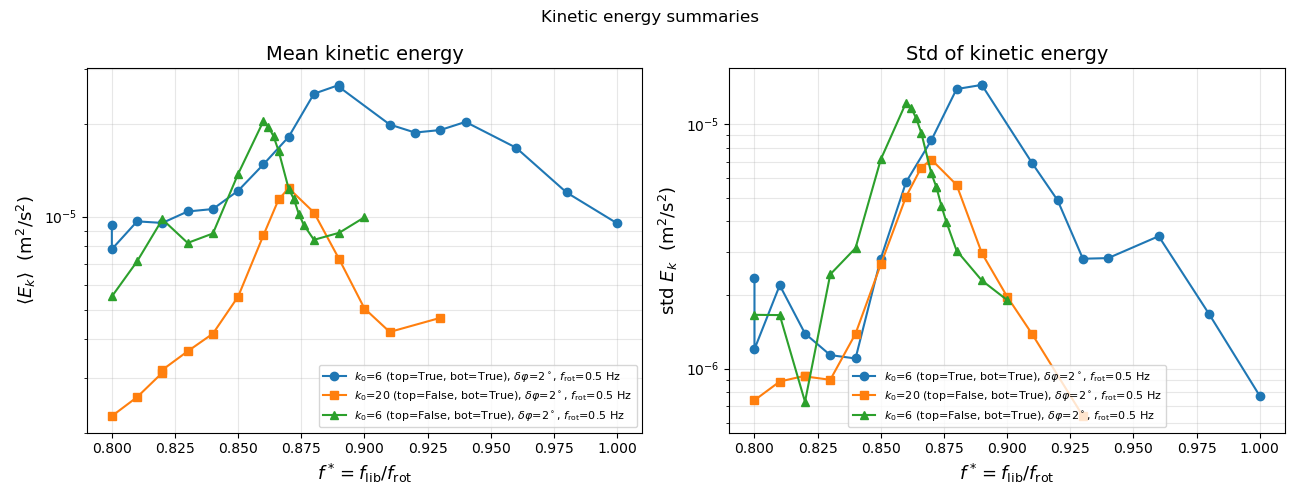

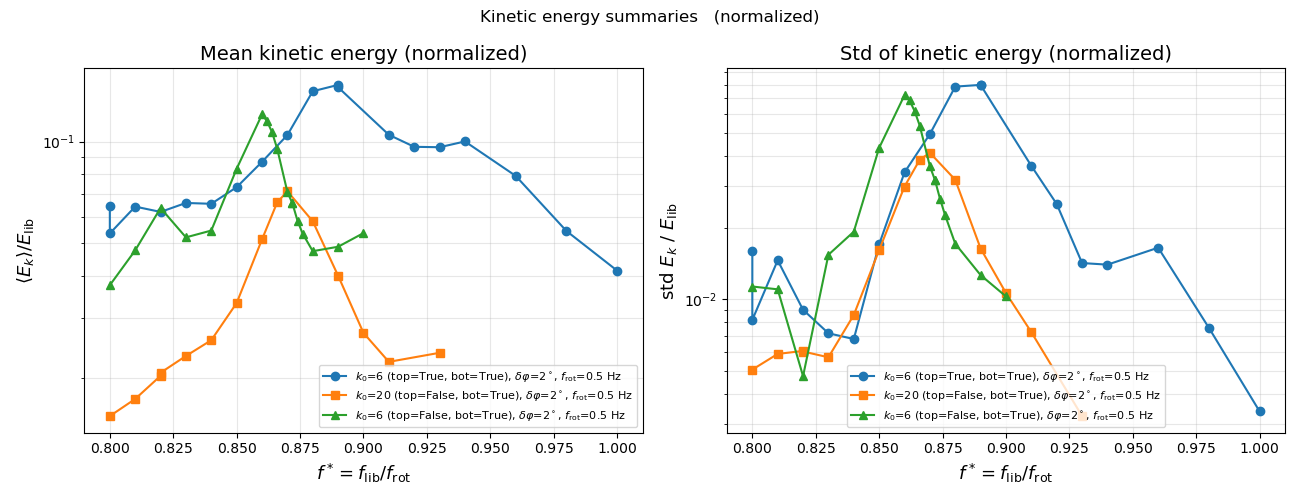

In [12]:
# The figure is built HERE (cell top level) so the %matplotlib widget backend
# shows it interactively. Both raw and normalized are saved; a filtered view
# gets a '_filtered' tag so it never overwrites the full resonance figure.
_stem = OUTPUT_STEM or os.path.join(_CEG, "KineticEnergy_vs_fstar_overlay")
_ftag = "" if no_filter else "_filtered"

for _norm in (False, True):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    if not draw_summary(axes, summaries_sel, normalize=_norm):
        plt.close(fig)
        print("Nothing to plot.")
        continue
    fig.suptitle("Kinetic energy summaries%s"
                 % ("   (normalized)" if _norm else ""), fontsize=12)
    fig.tight_layout()
    out = figure_filename(_stem + _ftag, FIG_FORMAT, normalized=_norm)
    fig.savefig(out, dpi=200, bbox_inches="tight")
    print("Figure written to:\n  %s" % out)


Figure written to:
  /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/VelocityFFT_amp_flib_overlay_filtered.png


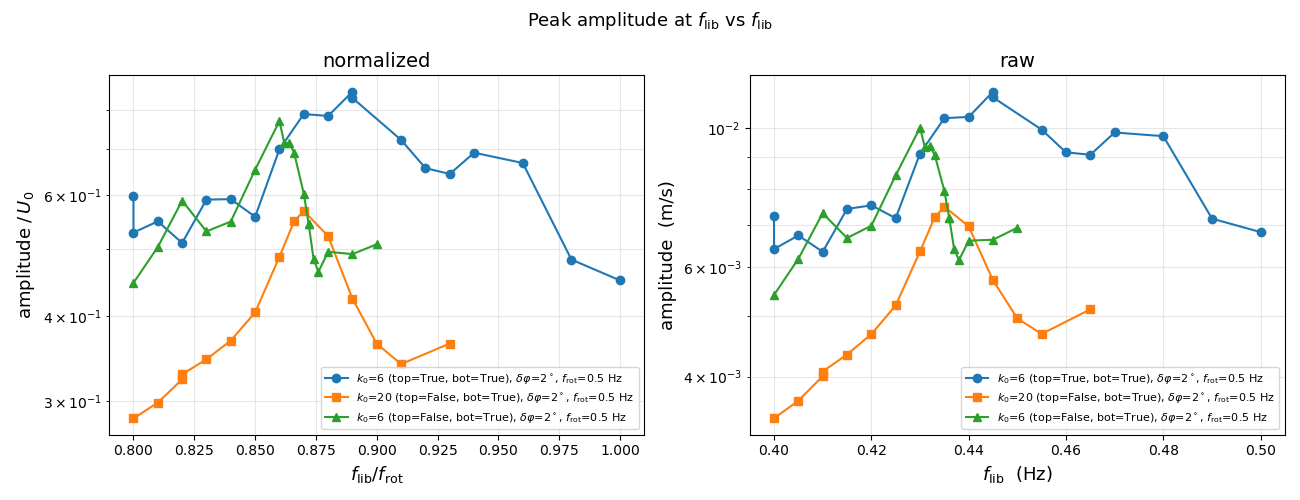

In [13]:
# Peak amplitude at f_lib vs f_lib (left normalized /U0, right raw).
# 'overlay' name -> saved in _CEG.
_ft = "" if no_filter else "_filtered"
if any(not s["df"].empty for s in vfft_summaries_sel):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    draw_amp_summary(axes, vfft_summaries_sel, ["flib"])
    fig.suptitle(r"Peak amplitude at $f_{\mathrm{lib}}$ vs $f_{\mathrm{lib}}$",
                 fontsize=13)
    fig.tight_layout()
    _out = figure_filename(os.path.join(_CEG, "VelocityFFT_amp_flib_overlay" + _ft),
                           FIG_FORMAT)
    fig.savefig(_out, dpi=200, bbox_inches="tight")
    print("Figure written to:\n  %s" % _out)
else:
    print("No VelocityFFT summaries -- amp(f_lib) figure skipped.")


Figure written to:
  /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/VelocityFFT_amp_flow_overlay_filtered.png


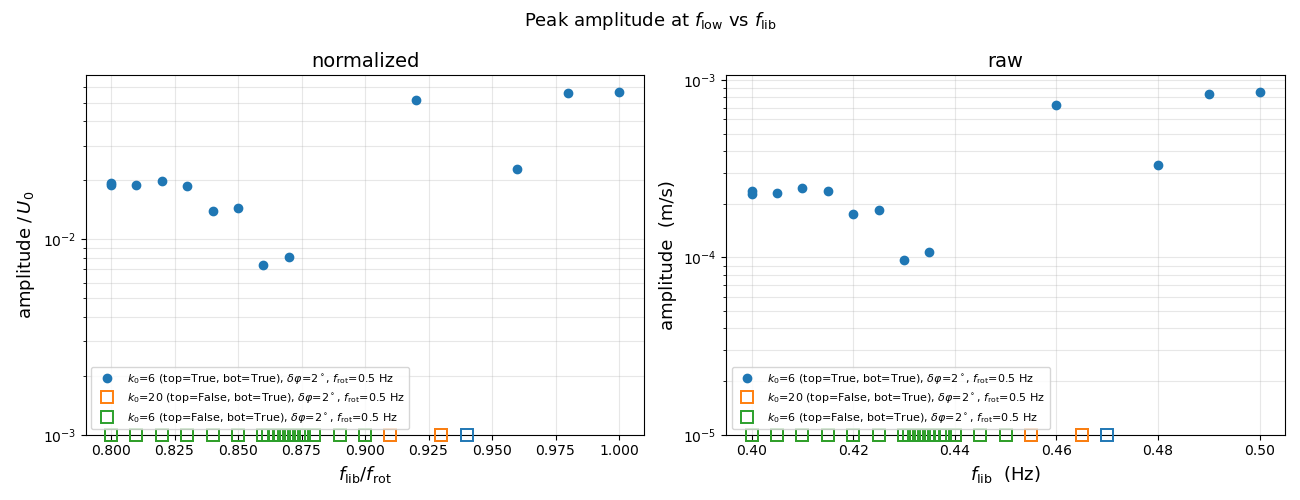

In [14]:
# Peak amplitude at f_low vs f_lib (left normalized /U0, right raw).
# 'overlay' name -> saved in _CEG.
_ft = "" if no_filter else "_filtered"
if any(not s["df"].empty for s in vfft_summaries_sel):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    draw_amp_summary(axes, vfft_summaries_sel, ["flow"], nan_as_floor=True)
    fig.suptitle(r"Peak amplitude at $f_{\mathrm{low}}$ vs $f_{\mathrm{lib}}$", fontsize=13)
    fig.tight_layout()
    _out = figure_filename(os.path.join(_CEG, "VelocityFFT_amp_flow_overlay" + _ft),
                           FIG_FORMAT)
    fig.savefig(_out, dpi=200, bbox_inches="tight")
    print("Figure written to:\n  %s" % _out)
else:
    print("No VelocityFFT summaries -- amp(flow) figure skipped.")


Figure written to:
  /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/VelocityFFT_amp_flib_minus_flow_overlay_filtered.png


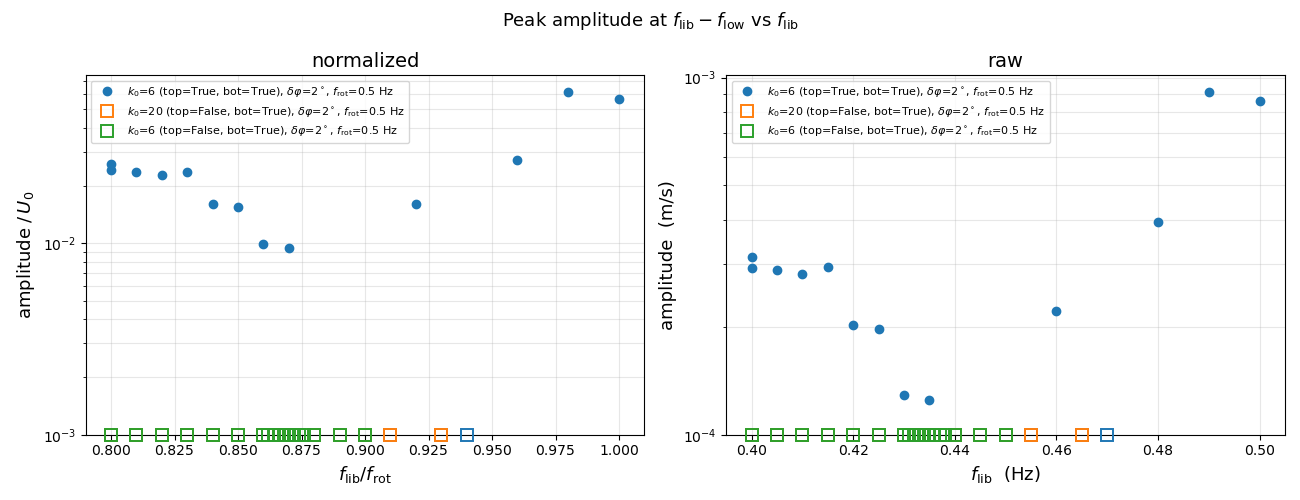

In [15]:
# Peak amplitude at f_lib - f_low vs f_lib (left normalized /U0, right raw).
# 'overlay' name -> saved in _CEG.
_ft = "" if no_filter else "_filtered"
if any(not s["df"].empty for s in vfft_summaries_sel):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    draw_amp_summary(axes, vfft_summaries_sel, ["flib_minus_flow"], nan_as_floor=True)
    fig.suptitle(r"Peak amplitude at $f_{\mathrm{lib}}-f_{\mathrm{low}}$ vs $f_{\mathrm{lib}}$", fontsize=13)
    fig.tight_layout()
    _out = figure_filename(os.path.join(_CEG, "VelocityFFT_amp_flib_minus_flow_overlay" + _ft),
                           FIG_FORMAT)
    fig.savefig(_out, dpi=200, bbox_inches="tight")
    print("Figure written to:\n  %s" % _out)
else:
    print("No VelocityFFT summaries -- amp(flib_minus_flow) figure skipped.")


Figure written to:
  /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/VelocityFFT_amp_flib_plus_flow_overlay_filtered.png


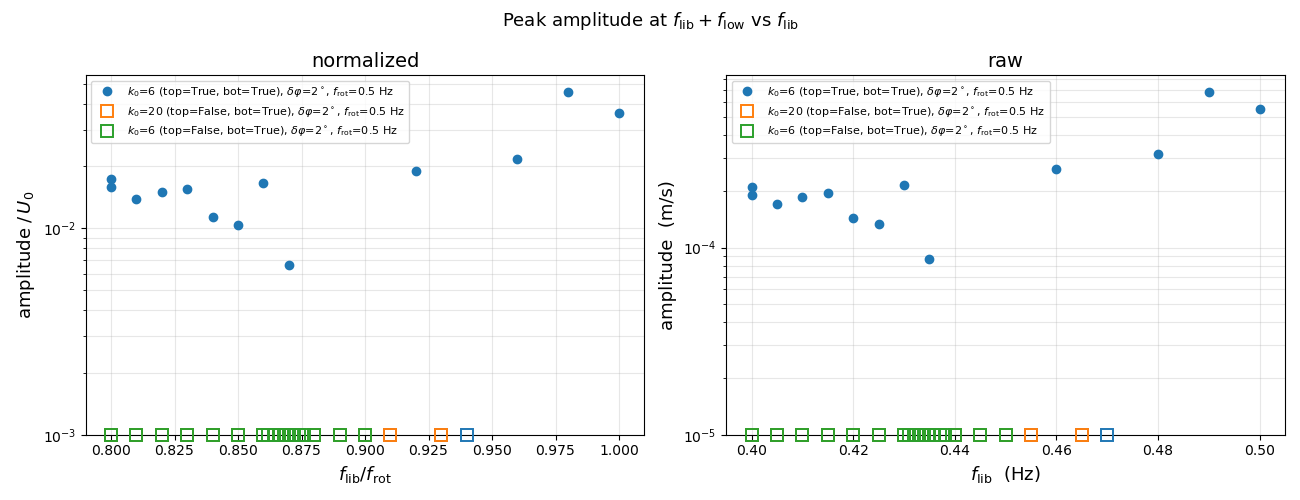

In [16]:
# Peak amplitude at f_lib + f_low vs f_lib (left normalized /U0, right raw).
# 'overlay' name -> saved in _CEG.
_ft = "" if no_filter else "_filtered"
if any(not s["df"].empty for s in vfft_summaries_sel):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    draw_amp_summary(axes, vfft_summaries_sel, ["flib_plus_flow"], nan_as_floor=True)
    fig.suptitle(r"Peak amplitude at $f_{\mathrm{lib}}+f_{\mathrm{low}}$ vs $f_{\mathrm{lib}}$", fontsize=13)
    fig.tight_layout()
    _out = figure_filename(os.path.join(_CEG, "VelocityFFT_amp_flib_plus_flow_overlay" + _ft),
                           FIG_FORMAT)
    fig.savefig(_out, dpi=200, bbox_inches="tight")
    print("Figure written to:\n  %s" % _out)
else:
    print("No VelocityFFT summaries -- amp(flib_plus_flow) figure skipped.")


Figure written to:
  /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/KineticEnergyFFT_amp_2flib_overlay_filtered.png


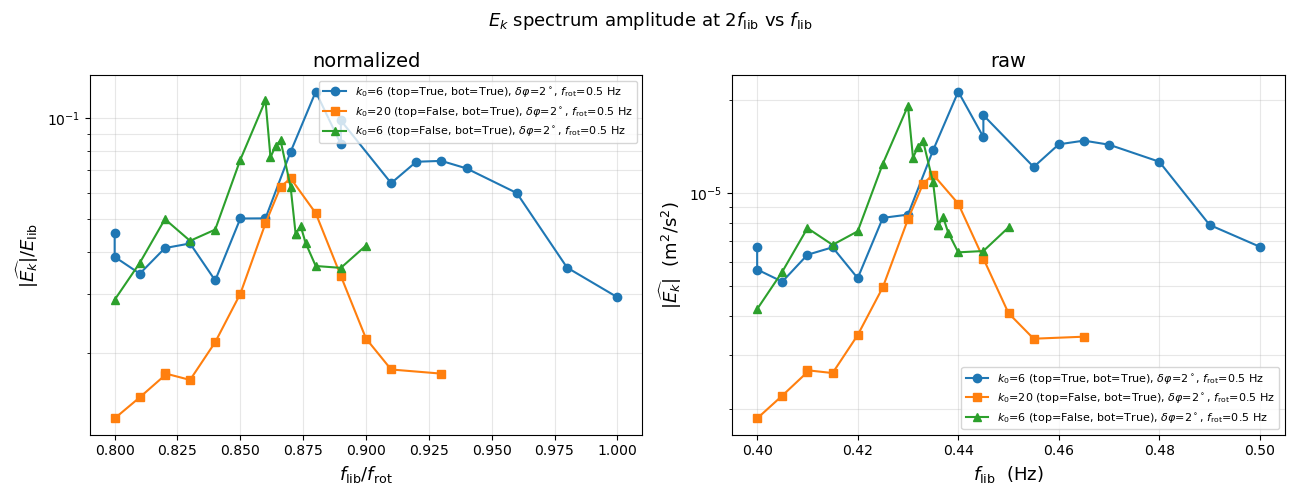

In [17]:
# Ek-spectrum peak amplitude at f_lib and 2*f_lib vs f_lib (left normalized
# /E_lib, right raw). 'overlay' name -> saved in _CEG.
_ft = "" if no_filter else "_filtered"
if any(not s["df"].empty for s in kefft_summaries_sel):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    draw_amp_summary(axes, kefft_summaries_sel, ["2flib"],
                     ylab_star=r"$|\widehat{E_k}| / E_{\mathrm{lib}}$",
                     ylab_raw=r"$|\widehat{E_k}|$  (m$^2$/s$^2$)")
    fig.suptitle(r"$E_k$ spectrum amplitude at $2f_{\mathrm{lib}}$ vs $f_{\mathrm{lib}}$",
                 fontsize=13)
    fig.tight_layout()
    _out = figure_filename(os.path.join(_CEG, "KineticEnergyFFT_amp_2flib_overlay" + _ft),
                           FIG_FORMAT)
    fig.savefig(_out, dpi=200, bbox_inches="tight")
    print("Figure written to:\n  %s" % _out)
else:
    print("No KineticEnergyFFT summaries -- Ek amp figure skipped.")
